# Writing your own sweeps

In [the quickstart](01_quickstart.ipynb) we used two small sweeps — `average_children` and `propagate` — to introduce the API. This notebook goes deeper:

1. **Anatomy of a sweep declaration** — `reads / reads_children / reads_parent / writes` and what happens when you get them wrong.
2. **Equal-degree vs unequal-degree trees** — the same user code dispatches to two different backends; understanding the boundary saves you from surprises.
3. **The children-axis reduction surface** — `.sum / .prod / .max / .min / .mean(axis=0)`.
4. **Pattern: subtree size** — count nodes per subtree with a single up-sweep that reads both `node` and `children`.
5. **Pattern: depth from root** — propagate root → leaf with a down-sweep.

By the end you will have written several sweeps from scratch and have a working mental model of the dispatcher.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import hyperiax as hx


def plot_tree(topo, values=None, ax=None, title=None, cmap='viridis',
              vmin=None, vmax=None, label_format=None):
    """Layered top-down layout. (Same helper as 01_quickstart.ipynb, with optional value labels.)"""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    pos = np.zeros((topo.size, 2))
    for d in range(topo.depth + 1):
        lo, hi = int(topo.level_starts[d]), int(topo.level_starts[d + 1])
        n = hi - lo
        pos[lo:hi, 0] = np.linspace(0, 1, n + 2)[1:-1] if n > 1 else 0.5
        pos[lo:hi, 1] = -d
    for i in range(1, topo.size):
        p = int(topo.parents[i])
        ax.plot([pos[p, 0], pos[i, 0]], [pos[p, 1], pos[i, 1]],
                'k-', lw=0.6, alpha=0.5, zorder=1)
    if values is None:
        ax.scatter(pos[:, 0], pos[:, 1], s=420, c='lightsteelblue',
                   edgecolor='k', zorder=3)
        for i in range(topo.size):
            ax.text(pos[i, 0], pos[i, 1], str(i), ha='center', va='center', fontsize=8)
    else:
        v = np.asarray(values)
        sc = ax.scatter(pos[:, 0], pos[:, 1], s=480, c=v,
                        edgecolor='k', cmap=cmap, vmin=vmin, vmax=vmax, zorder=3)
        plt.colorbar(sc, ax=ax, label='value', shrink=0.8)
        fmt = label_format or (lambda x: f'{x:.0f}' if abs(x - round(x)) < 1e-6 else f'{x:.2g}')
        for i in range(topo.size):
            ax.text(pos[i, 0], pos[i, 1], fmt(float(v[i])),
                    ha='center', va='center', fontsize=7, color='white')
    if title:
        ax.set_title(title, fontsize=11)
    ax.set_axis_off()
    return ax

## 1. Anatomy of a sweep declaration

Every sweep is a Python function wrapped by `@hx.up` or `@hx.down`. The decorator captures four pieces of metadata that act as a contract between you and the dispatcher:

| kwarg | Meaning | Default if omitted |
|---|---|---|
| `reads` | Fields read from the **current node**. Available as `node.X` inside the function. | All schema fields |
| `reads_children` (up only) | Fields read from **each child**. Available as `children.X`. | All schema fields |
| `reads_parent` (down only) | Fields read from **the parent**. Available as `parent.X`. | All schema fields |
| `writes` | Fields the function returns. The returned `dict` must have exactly these keys. | **Required** — no default |

The dispatcher uses these declarations to slice the right data, hand you a view, and scatter the right results back. Anything you didn't declare is hidden from your function, and anything you return that you didn't declare is rejected. Being explicit pays off when sweeps get bigger or read from many fields.

In [2]:
topo = hx.symmetric_topology(depth=2, degree=3)   # 1+3+9 = 13 nodes

tree = hx.Tree.empty(topo, {'value': (), 'weight': ()})
tree = tree.at[topo.is_leaf].set(value=jnp.ones(int(topo.is_leaf.sum())))
tree = tree.set(weight=jnp.linspace(1, 2, topo.size, dtype=jnp.float32))

@hx.up(
    reads=('value',),                   # from the current node we look at: value
    reads_children=('value', 'weight'), # from each child we look at:     value, weight
    writes=('value',),                  # we promise to write back:        value
)
def aggregate(node, children, params):
    # Inside an equal-degree up-sweep the user fn is vmapped, so per parent:
    #   node.value        : shape ()       — one parent at a time
    #   children.value    : shape (k,)     — k children, scalar field
    #   children.weight   : shape (k,)
    # params is whatever you pass via sweep(tree, params=...), which is a global read-only constant during the sweep. Here we just use it to pass a bias term that gets added at every node.
    weighted = (children.value * children.weight).sum(0)
    return {'value': weighted + node.value + params['bias']}

new_tree = aggregate(tree, params={'bias': 0.1})
print('OK. Root value:', float(new_tree.value[0]))

OK. Root value: 18.07499885559082


### Mistake #1 — reading a field you didn't declare

The view only exposes what you declared in `reads / reads_children / reads_parent`. Anything else raises `AttributeError`, with a helpful list of what *is* available.

(If you leave a `reads_*` kwarg off, it defaults to "all schema fields" — convenient for one-shot prototypes, but stricter explicit lists pay off as your sweep grows: typos in field names get flagged immediately.)

In [3]:
@hx.up(reads_children=('value',),   # forgot 'weight' in reads_children!
       writes=('value',))
def forgot_to_declare(node, children, params):
    # children.weight isn't in scope because we didn't list it in reads_children.
    return {'value': (children.value * children.weight).sum(0)}

try:
    forgot_to_declare(tree)
except AttributeError as e:
    print('AttributeError:')
    print(' ', e)

AttributeError:
  Children field 'weight' is not available in this scope. Add it to `reads_children=...` on the sweep. Available: ['value']


### Mistake #2 — returning the wrong keys

The returned `dict` must have exactly the same key set as `writes`. Extras or missing keys both raise `SchemaMismatch`.

In [4]:
@hx.up(reads_children=('value',), writes=('value',))
def wrong_writes(node, children, params):
    return {'value': children.value.sum(0),
            'extra': children.value.sum(0)}  # not in writes

try:
    wrong_writes(tree)
except hx.SchemaMismatch as e:
    print('SchemaMismatch:')
    print(' ', e)

SchemaMismatch:
  Up-sweep returned keys ['extra', 'value'] but writes=['value']. Extra: ['extra']; missing: [].


## 2. Equal-degree vs unequal-degree trees

Hyperiax has two dispatch backends:

- **Equal-degree** — every non-leaf has the same number of children. The dispatcher gathers children into a dense `(scope, k, *trailing)` array and `jax.vmap`s your function per parent. Inside the body, `node.X` is `(*trailing,)` and `children.X` is `(k, *trailing)` — real arrays you can slice or do arithmetic on.
- **Unequal-degree** — children counts vary per node. The dispatcher concatenates each level's children into a flat array and assigns segment ids; reductions go through `jax.ops.segment_*`. Inside the body, `node.X` is batched `(num_parents_at_level, *trailing)`, and `children.X` is a `ChildrenAxis` proxy that supports `.sum / .prod / .max / .min / .mean(axis=0)` but not arithmetic or indexing.

**The crucial property: identical user code works on both** — as long as the only operations on the children axis are the supported reductions.

equal-degree topology:
  equal_degree=True  child_counts(non-leaf)=[2, 2, 2]
unequal-degree topology:
  equal_degree=False  child_counts(non-leaf)=[2, 3, 1, 2]


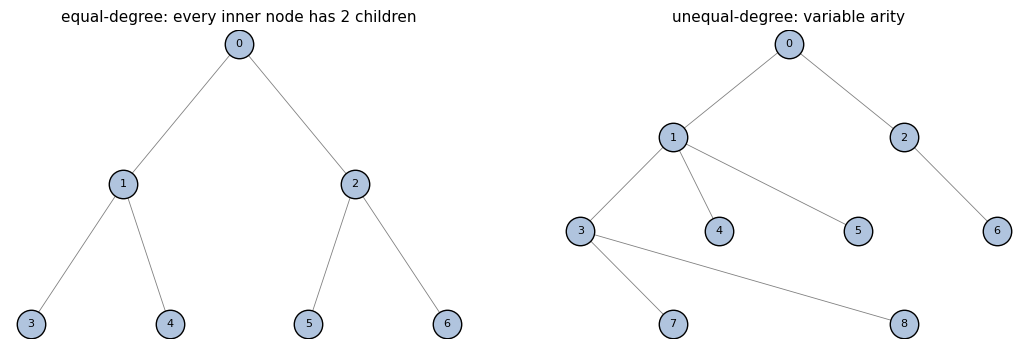

In [5]:
# Equal-degree: depth-2 binary tree, every inner node has 2 children.
topo_eq = hx.symmetric_topology(depth=2, degree=2)

# Unequal-degree: ragged tree (root has 2 children; node 1 has 3; node 2 has 1; node 3 has 2).
topo_uneq = hx.from_parents([0, 0, 0, 1, 1, 1, 2, 3, 3])

print('equal-degree topology:')
print(f'  equal_degree={topo_eq.equal_degree}  child_counts(non-leaf)={topo_eq.child_counts[~topo_eq.is_leaf].tolist()}')
print('unequal-degree topology:')
print(f'  equal_degree={topo_uneq.equal_degree}  child_counts(non-leaf)={topo_uneq.child_counts[~topo_uneq.is_leaf].tolist()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_tree(topo_eq, ax=axes[0], title='equal-degree: every inner node has 2 children')
plot_tree(topo_uneq, ax=axes[1], title='unequal-degree: variable arity')
plt.show()

equal-degree   root = 4.0    (expected leaf count = 4)
unequal-degree root = 5.0    (expected leaf count = 5)


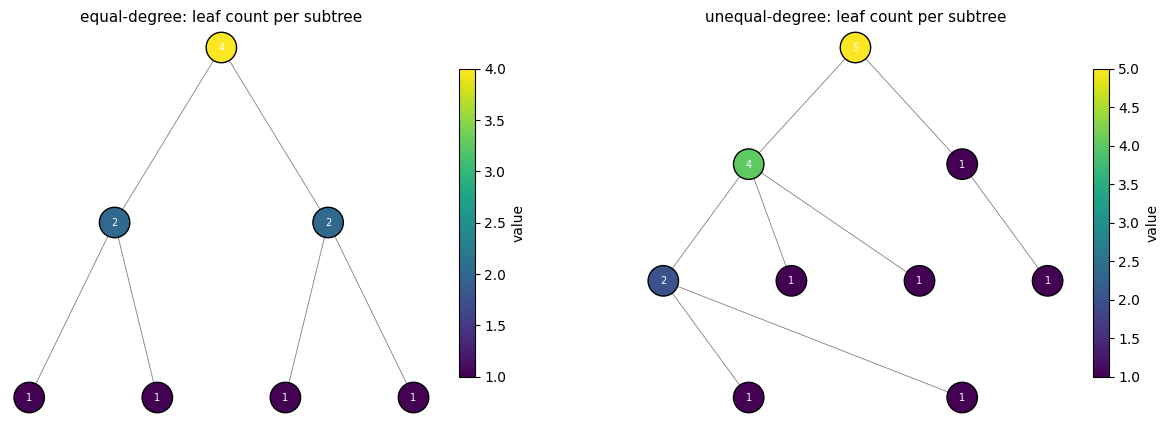

In [6]:
# Same up-sweep, run on both topologies.
@hx.up(reads_children=('value',), writes=('value',))
def sum_subtree(node, children, params):
    return {'value': children.value.sum(0)}

# Seed each tree's leaves with 1.0, so summing yields the leaf count.
tree_eq = hx.Tree.empty(topo_eq, {'value': ()})
tree_eq = tree_eq.at[topo_eq.is_leaf].set(value=jnp.ones(int(topo_eq.is_leaf.sum())))

tree_uneq = hx.Tree.empty(topo_uneq, {'value': ()})
tree_uneq = tree_uneq.at[topo_uneq.is_leaf].set(value=jnp.ones(int(topo_uneq.is_leaf.sum())))

out_eq   = sum_subtree(tree_eq)
out_uneq = sum_subtree(tree_uneq)

print(f'equal-degree   root = {float(out_eq.value[0])}    (expected leaf count = {int(topo_eq.is_leaf.sum())})')
print(f'unequal-degree root = {float(out_uneq.value[0])}    (expected leaf count = {int(topo_uneq.is_leaf.sum())})')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_tree(topo_eq, out_eq.value, ax=axes[0],
          title='equal-degree: leaf count per subtree')
plot_tree(topo_uneq, out_uneq.value, ax=axes[1],
          title='unequal-degree: leaf count per subtree')
plt.show()

Note what just happened: **we wrote one function, and it worked correctly on a 7-node binary tree and on a 9-node ragged tree with no changes**. The dispatcher picked the right backend by inspecting `topo.equal_degree` at call time.

The one thing to watch out for on unequal-degree trees: `children.X` is a proxy, not an array. So `children.value * children.weight` (elementwise on the children axis) is rejected — you'd have to precompute the product into its own field before the sweep. On equal-degree trees there is no such restriction. If your project always uses symmetric trees you can forget the distinction entirely; if it sometimes does both, stick to operations that go through `.sum / .prod / .max / .min / .mean`.

## 3. The children-axis reduction surface

Five reductions, all reducing over the children axis (`axis=0`):

- `children.X.sum(0)`
- `children.X.prod(0)`
- `children.X.max(0)`
- `children.X.min(0)`
- `children.X.mean(0)`

Each returns an array of the same trailing shape as `X`, one record per parent. We'll run all five on the same input to see them in action.

We use a height-2 ternary tree (1 + 3 + 9 = 13 nodes) and seed the 9 leaves with `[1, 2, …, 9]`. At depth 1, each of the three inner nodes has children `[1, 2, 3]`, `[4, 5, 6]`, `[7, 8, 9]`.

In [7]:
topo3 = hx.symmetric_topology(depth=2, degree=3)
tree3 = hx.Tree.empty(topo3, {'value': ()})
tree3 = tree3.at[topo3.is_leaf].set(value=jnp.arange(1, 10, dtype=jnp.float32))

def _make_reducer(reduce_fn):
    @hx.up(reads_children=('value',), writes=('value',))
    def sweep(node, children, params):
        return {'value': reduce_fn(children.value)}
    return sweep

sweeps = {
    'sum':  _make_reducer(lambda x: x.sum(0)),
    'prod': _make_reducer(lambda x: x.prod(0)),
    'max':  _make_reducer(lambda x: x.max(0)),
    'min':  _make_reducer(lambda x: x.min(0)),
    'mean': _make_reducer(lambda x: x.mean(0)),
}

print(f"{'reduction':<6} {'root':>10}   depth-1 inner values")
print('-' * 50)
for label, sw in sweeps.items():
    out = sw(tree3)
    print(f'{label:<6} {float(out.value[0]):>10.1f}   {np.asarray(out.value[1:4])}')

# Sanity-check one nice number: the full-tree product is 9! = 362880.
assert int(sweeps['prod'](tree3).value[0]) == 362880

reduction       root   depth-1 inner values
--------------------------------------------------
sum          45.0   [ 6. 15. 24.]
prod     362880.0   [  6. 120. 504.]
max           9.0   [3. 6. 9.]
min           1.0   [1. 4. 7.]
mean          5.0   [2. 5. 8.]


Worth noting: each call to `_make_reducer` creates a **fresh `SweepFn`** — a separately hashable, JIT-cached transform. The factory pattern is useful when you want the same body parametrized by a small callable (a reduction, a kernel, a similarity function). The dispatcher hashes on `(direction, fn identity, reads/writes spec)`, so two sweeps built by the factory don't share a cache entry.

## 4. Pattern — subtree size

**Problem:** for every node, count how many nodes are in the subtree rooted there (including itself).

**Recursion:** `size(leaf) = 1`; `size(inner) = 1 + Σ size(child)`. We seed every node with `count = 1`, then run an up-sweep that adds the children's counts to the node's own. Inner nodes get overwritten with the correct subtree size; leaves are never visited and keep their seed of 1.

This sweep is interesting because it reads **both** `node.count` (the seed) and `children.count` (already-computed subtree sizes one level deeper). It's our first sweep using the `reads=` argument.

subtree sizes per node: [9, 6, 2, 3, 1, 1, 1, 1, 1]
root subtree size       = 9 (= total nodes = 9) ✓


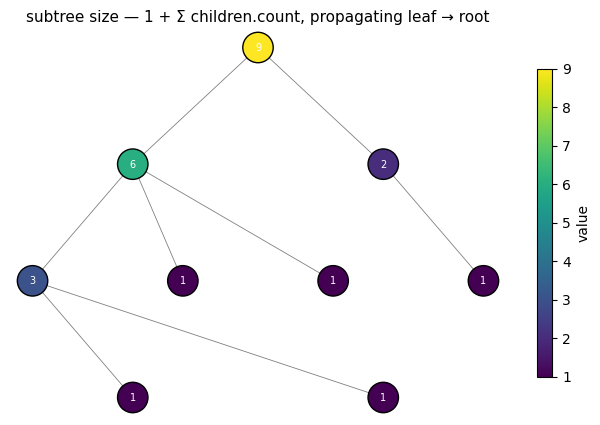

In [8]:
# Use the ragged tree from §2 — it makes the result more visually interesting.
tree_size = hx.Tree.empty(topo_uneq, {'count': ()})
tree_size = tree_size.set(count=jnp.ones(topo_uneq.size, dtype=jnp.float32))

@hx.up(reads=('count',), reads_children=('count',), writes=('count',))
def subtree_size(node, children, params):
    return {'count': node.count + children.count.sum(0)}

out_size = subtree_size(tree_size)

counts = np.asarray(out_size.count).astype(int)
print(f'subtree sizes per node: {counts.tolist()}')
print(f'root subtree size       = {counts[0]} (= total nodes = {topo_uneq.size}) ✓')

plot_tree(topo_uneq, out_size.count,
          title='subtree size — 1 + Σ children.count, propagating leaf → root')
plt.show()

## 5. Pattern — depth from root

**Problem:** for every node, record its depth (root = 0, root's children = 1, grandchildren = 2, …).

**Recursion:** `depth(root) = 0`; `depth(node) = depth(parent) + 1`. A down-sweep is the natural fit. The root is never visited by `@hx.down` (it has no parent), so we leave it at the schema's default value of 0.

This sweep does **not** read `node` at all — we set `reads=()` to say so explicitly. Setting `reads=()` is a small ergonomic win: the dispatcher hands you an empty `node` view and any typo like `node.X` raises a clear error rather than silently being a no-op.

depths per node:           [0, 1, 1, 2, 2, 2, 2, 3, 3]
matches topo.node_depths?  True


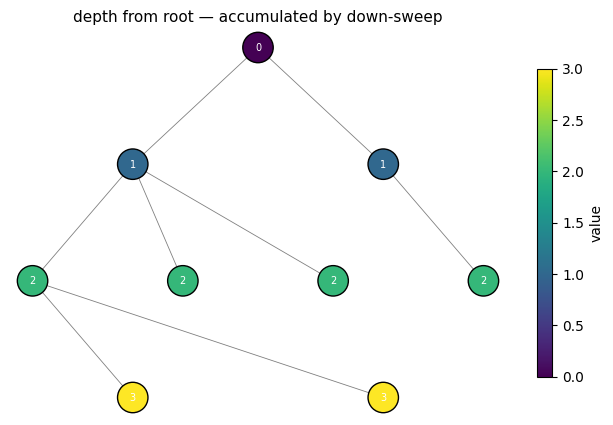

In [9]:
tree_d = hx.Tree.empty(topo_uneq, {'depth': ()})
# root.depth = 0 already (Tree.empty zeros everything), and the down-sweep never visits the root.

@hx.down(reads=(), reads_parent=('depth',), writes=('depth',))
def assign_depth(node, parent, params):
    return {'depth': parent.depth + 1.0}

out_depth = assign_depth(tree_d)

depths = np.asarray(out_depth.depth).astype(int)
print(f'depths per node:           {depths.tolist()}')
print(f'matches topo.node_depths?  {np.array_equal(depths, np.asarray(topo_uneq.node_depths))}')

plot_tree(topo_uneq, out_depth.depth,
          title='depth from root — accumulated by down-sweep')
plt.show()

## Recap & next steps

What you wrote in this notebook:

1. `aggregate` — a kitchen-sink up-sweep showing all four declaration kwargs plus `params`.
2. `sum_subtree` — one function body running unchanged on equal-degree and unequal-degree trees.
3. Five reducer sweeps via a factory — `sum / prod / max / min / mean` on the children axis.
4. `subtree_size` — an up-sweep reading both `node` and `children`.
5. `assign_depth` — a down-sweep reading only `parent` (`reads=()`).

Things to keep in your head:

- **`writes=` is required** and the returned dict's key set must match it exactly. Everything else can default.
- **Inside the function, shapes are per-parent on equal-degree trees and batched-per-level on unequal-degree trees**, but reductions like `.sum(0)` are written identically in both modes.
- **Children-axis arithmetic** (`children.x * children.y`, `children.x[0]`, `jnp.where(children.x > 0, …)`) **works only on equal-degree trees**. On unequal-degree trees the children axis is a virtual proxy; precompute elementwise expressions into their own field before the sweep if you need them.
- **A `SweepFn` is hashable.** The dispatcher uses it as a JIT static argument and reuses compilations — calling `sum_subtree(tree)` a hundred times only compiles once.

Where to go next:

- **`03_phylo_mean.ipynb`** — read a real Newick tree, run the `phylo_mean` prebuilt.
- **`04_phylo_bayesian.ipynb`** — Bayesian ancestral states (closed-form Gaussian posterior, exact smoothing via BFFG).
- **`05_gaussian_mcmc.ipynb`** — drop "known hyperparameters" and run MCMC on the joint state-plus-hyperparameter posterior; uses these sweeps inside `lax.scan`.
- **`06_gaussian_mle.ipynb`** — `jax.grad` through the same sweeps for gradient-based hyperparameter learning.